# Fase 2 — Descomposición de la Serie
### Time Series Forecasting (PJM Energy) · Omar Mora Flores

Descomponemos la serie en **tendencia + estacionalidad + residuo**, testeamos estacionariedad
(ADF) y preparamos el **split cronológico** para forecasting.

In [1]:
import numpy as np, pandas as pd, pickle
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ROOT = Path.cwd()
while not (ROOT / "data" / "PJME_hourly.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"; REPORTS.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":130,"axes.titleweight":"bold"})

s = (pd.read_csv(ROOT/"data"/"PJME_hourly.csv", parse_dates=["Datetime"])
       .drop_duplicates("Datetime").sort_values("Datetime").set_index("Datetime")["PJME_MW"])
daily = s.asfreq("h").interpolate().resample("D").mean()
print("Serie diaria:", len(daily), "puntos")

Serie diaria: 6059 puntos


## 2.1 Descomposición STL (estacionalidad anual)

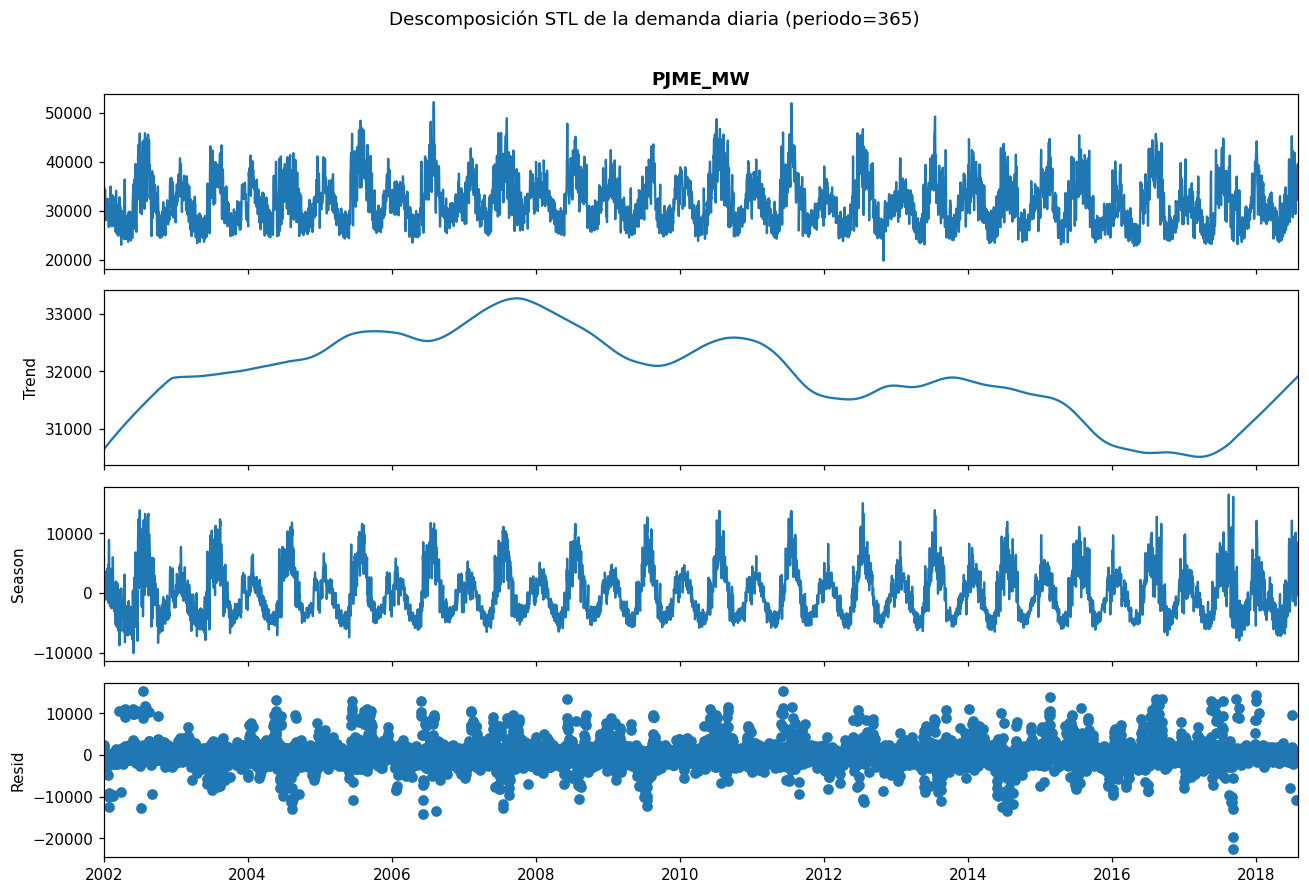

Fuerza estacional aprox: 0.621


In [2]:
stl = STL(daily, period=365, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(12, 8)
fig.suptitle("Descomposición STL de la demanda diaria (periodo=365)", y=1.01)
fig.tight_layout(); fig.savefig(REPORTS/"04_decomposition.png", bbox_inches="tight"); plt.show()
print("Fuerza estacional aprox:", round(1 - stl.resid.var()/(stl.seasonal+stl.resid).var(), 3))

## 2.2 Estacionariedad (ADF) y diferenciación

In [3]:
def adf_p(x): return adfuller(x.dropna())[1]
print(f"ADF p-value serie       : {adf_p(daily):.4f}")
print(f"ADF p-value diferenciada: {adf_p(daily.diff()):.4f}")
print("=> Con 1 diferenciación la serie es estacionaria (p<0.05): d=1 para ARIMA")

ADF p-value serie       : 0.0000


ADF p-value diferenciada: 0.0000
=> Con 1 diferenciación la serie es estacionaria (p<0.05): d=1 para ARIMA


## 2.3 ACF y PACF (para los órdenes de ARIMA)

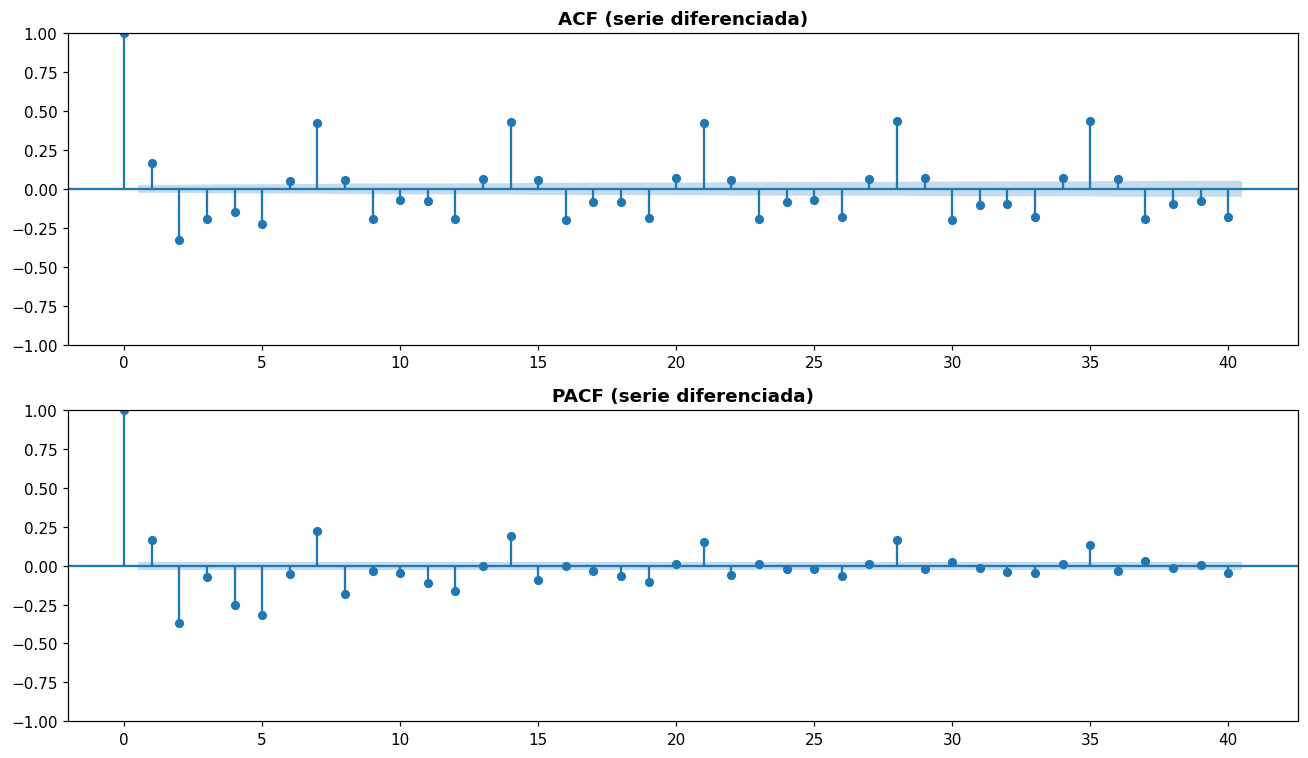

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(daily.diff().dropna(), lags=40, ax=ax[0]); ax[0].set_title("ACF (serie diferenciada)")
plot_pacf(daily.diff().dropna(), lags=40, ax=ax[1], method="ywm"); ax[1].set_title("PACF (serie diferenciada)")
fig.tight_layout(); fig.savefig(REPORTS/"05_acf_pacf.png", bbox_inches="tight"); plt.show()

## 2.4 Split cronológico (nunca aleatorio)

In [5]:
H = 90                       # horizonte de test: últimos 90 días
train, test = daily.iloc[:-H], daily.iloc[-H:]
print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} días)")
print(f"Test : {test.index.min().date()} -> {test.index.max().date()} ({len(test)} días)")

pickle.dump({"daily": daily, "train": train, "test": test, "H": H},
            open(ROOT/"data"/"splits.pkl","wb"))
print("Guardado data/splits.pkl  ·   Siguiente: 03_modeling.ipynb")

Train: 2002-01-01 -> 2018-05-05 (5969 días)
Test : 2018-05-06 -> 2018-08-03 (90 días)
Guardado data/splits.pkl  ·  ➡️ Siguiente: 03_modeling.ipynb
